In [1]:
import pandas as pd
import sqlite3

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')

    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']

    query = f"""
    SELECT 
        {', '.join(financial_indicators)} 
    FROM    
        balancetes_media_ano
    WHERE 
        cnpj IN (
            SELECT cnpj
            FROM balancetes_bancos_sociedades_media_ano
            GROUP BY ano, cnpj
        );"""

    df = pd.read_sql_query(query, conn)

    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']

    for col in colunas_para_limpar:
        df[col] = (df[col]
                .str.lower()
                .str.normalize('NFD')
                .str.replace(r'[\u0300-\u036f]', '', regex=True))

    # Padronizando nomes
    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
    df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
    df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
    df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
    df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
    df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
    df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
    df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
    df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
    df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
    df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
    df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
    df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
    df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
    df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
    df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
    df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
    df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
    df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
    df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
    df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
    df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
    df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
    df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
    df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
    df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
    df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
    df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
    df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
    df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"

    # Conta duplicada
    df = df[df['conta'] != 88000008]
    df = df[df['conta'] != 47100004]
    df = df[df['conta'] != 51100007]
    df = df[df['conta'] != 78100004]
    df = df[df['conta'] != 61000001]

    mapa_contas = (
        df.groupby('conta')['nome_conta']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    novo_mapeamento = {}

    for conta, nome in mapa_contas.items():
        conta_str = str(conta) # Garante que podemos verificar o início
        
        if conta_str.startswith('1'):
            novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'):
            novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'):
            novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'):
            novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'):
            novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'):
            novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'):
            novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'):
            novo_nome = f"compensacao passiva - {nome}"
        else:
            novo_nome = nome # Mantém o original se não houver regra
            
        novo_mapeamento[conta] = novo_nome

    mapa_contas = novo_mapeamento

    df = df.pivot(
        index=['ano', 'cnpj', 'nome', 'taxonomia'],
        columns='conta',
        values='saldo'
    ).reset_index()
    df['ano'] = df['ano'].astype(int)

    # Valor mínimo da conta operações de crédito
    df = df[df[16000001] > 1000000]
    #df = df[df['taxonomia'] != 'sociedade de credito ao microempreendedor']

    df_original = df.copy()

    # Dividindo os valores pelo Ativo Total (39999993)
    colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia', 39999993]]
    for col in colunas_a_dividir:
        df[col] = df[col] / df[39999993]
    df.drop(columns=[39999993, 99999995], inplace=True)
    df_filtrado = df

    df_original = df_original.rename(columns=novo_mapeamento)
    df = df.rename(columns=novo_mapeamento)
    return df, df_original

df, df_original = dados_bancos()


In [2]:
# Eliminando colunas esparsas

def eliminar_colunas_esparsas(df, df_original):
    # 1. Calcular a porcentagem de nulos em cada coluna
    #esparsidade = df.isnull().sum() / len(df)
    esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
    # 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
    print(f"Colunas com > 10% de nulos: {sum(esparsidade > 0.10)}")
    print(f"Colunas com > 20% de nulos: {sum(esparsidade > 0.20)}")
    print(f"Colunas com > 30% de nulos: {sum(esparsidade > 0.30)}")

    # 3. Definir o limiar
    limiar_corte = 0.30

    # Identificar colunas a serem removidas
    colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
    colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
    # 4. Criar o novo dataset filtrado
    df_filtrado = df.drop(columns=colunas_para_remover)
    df_original = df_original.drop(columns=colunas_para_remover)

    print(f"\nDimensão original: {df.shape[1]} colunas")
    print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
    df_filtrado.fillna(0, inplace=True)
    return df_filtrado, df_original

df_filtrado, df_original = eliminar_colunas_esparsas(df, df_original)

Colunas com > 10% de nulos: 171
Colunas com > 20% de nulos: 158
Colunas com > 30% de nulos: 146

Dimensão original: 207 colunas
Dimensão após corte de esparsidade: 60 colunas


In [3]:
# Normalização dos dados

import numpy as np
import seaborn as sns

def normalizar_dados(df_filtrado):
    X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'], axis=1)
    variaveis = pd.DataFrame({'Contas': [col for col in X.columns]})
    # X.dropna(axis=1, inplace=True)
    X.fillna(0, inplace=True)

    return X

X = normalizar_dados(df_filtrado)
# Usar um heatmap do seaborn
# Cmap='coolwarm' é ótimo, pois destaca cores diferentes para correlação positiva e negativa

corr_matrix = X.corr(method='pearson')
'''
sns.heatmap(
corr_matrix, 
annot=False,            # Não mostrar os números (seria ilegível com 159)
cmap='coolwarm', 
fmt=".2f",              # Formato de duas casas decimais
linewidths=.5,          # Linhas entre as células
vmin=-1, vmax=1         # Definir escala de -1 a 1
)
'''

'\nsns.heatmap(\ncorr_matrix, \nannot=False,            # Não mostrar os números (seria ilegível com 159)\ncmap=\'coolwarm\', \nfmt=".2f",              # Formato de duas casas decimais\nlinewidths=.5,          # Linhas entre as células\nvmin=-1, vmax=1         # Definir escala de -1 a 1\n)\n'

Redução de dimensionalidade

In [4]:
# Análise de Correlação para Identificar Variáveis Redundantes

def remover_colunas_redundantes(df_filtrado, X, corr_matrix):
    # 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
    corr_matrix_abs = corr_matrix.abs()

    # 2. Selecionar apenas o triângulo superior da matriz
    # Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

    # 3. Definir o Limiar de Corte (Threshold)
    # 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
    threshold = 0.95

    # Encontrar colunas que têm correlação > threshold com qualquer outra coluna
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
    print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
    print(to_drop)

    # Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
    X.drop(columns=to_drop, inplace=True)

    from sklearn.preprocessing import StandardScaler
    #from sklearn.preprocessing import RobustScaler
    scaler = StandardScaler()
    #scaler = RobustScaler()
    X.columns = X.columns.astype(str)
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
    df_identificadores = df_filtrado[colunas_id]
    X = df_filtrado.drop(columns=colunas_id, axis=1)
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled

X, X_scaled = remover_colunas_redundantes(df_filtrado, X, corr_matrix)


--- Contas Redundantes a Descartar (Correlação > 0.95) ---
Número de variáveis sugeridas para remoção: 12
['compensacao ativa - compensacao ativa', 'resultado credor - receitas operacionais', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'resultado devedor - (-) despesas administrativas', 'resultado devedor - (-) imposto de renda', 'compensacao passiva - compensacao passiva', 'compensacao passiva - titulos e valores mobiliarios', 'compensacao passiva - custodia de valores', 'compensacao passiva - controle', 'compensacao passiva - classificacao da carteira de creditos', 'compensacao passiva - operacoes de creditos e arrendamento mercantil']


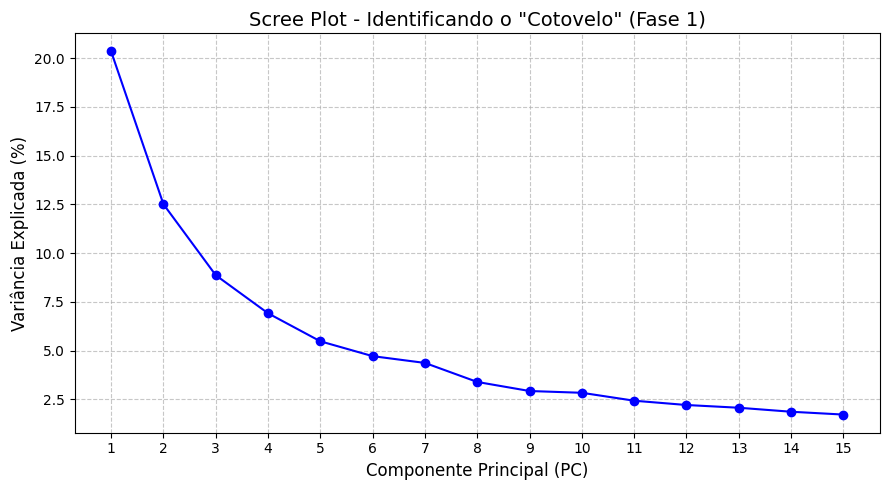

In [5]:
#Primeira aplicação do PCA para identificar os outliers

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def aplicar_pca_diagnostico(X_scaled):
    # 1. Rodamos o PCA com os primeiros 15 componentes apenas para ver a curva de queda
    pca_diagnostico = PCA(n_components=15, random_state=42)
    pca_diagnostico.fit(X_scaled)

    # 2. Extraímos a variância INDIVIDUAL de cada componente (em porcentagem)
    variancia_individual = pca_diagnostico.explained_variance_ratio_ * 100

    # 3. Desenhamos o Gráfico de Cotovelo
    plt.figure(figsize=(9, 5))
    plt.plot(range(1, 16), variancia_individual, marker='o', linestyle='-', color='b')

    plt.title('Scree Plot - Identificando o "Cotovelo" (Fase 1)', fontsize=14)
    plt.xlabel('Componente Principal (PC)', fontsize=12)
    plt.ylabel('Variância Explicada (%)', fontsize=12)
    plt.xticks(range(1, 16)) # Garante que todos os números de 1 a 15 apareçam no eixo X
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

aplicar_pca_diagnostico(X_scaled)

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def remover_outliers_por_ano(df_original, df_filtrado, X, X_scaled, limite_desvios, n_componentes_fase1):
    # 1. Separar os identificadores e a matriz numérica (X)
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']

    # Isola os identificadores para guardarmos
    df_identificadores = df_filtrado[colunas_id]


    bancos_normais_list = []
    bancos_outliers_list = []
    historico_variancia = []

    # 2. Iniciar a "Máquina do Tempo" (Loop ano a ano)
    for ano_atual in df_identificadores['ano'].unique():
        
        # Filtrar o ano atual tanto na matriz X quanto nos identificadores
        mascara_ano = (df_identificadores['ano'] == ano_atual)
        X_ano = X[mascara_ano]
        id_ano = df_identificadores[mascara_ano]
        
        # Se por acaso algum ano não tiver dados, pula para o próximo
        if X_ano.empty:
            continue
            
        # Padronizar os dados EXCLUSIVAMENTE com a média deste ano
        scaler_ano = StandardScaler()
        X_ano_padronizado = scaler_ano.fit_transform(X_ano)
        
        # Rodar o PCA diagnóstico para este ano
        pca_ano = PCA(n_components=n_componentes_fase1, random_state=42)
        pca_array_ano = pca_ano.fit_transform(X_ano_padronizado)
        df_pca_ano = pd.DataFrame(pca_array_ano, index=X_ano.index)

        variancia_percentual = pca_ano.explained_variance_ratio_ * 100
        
        # Salvar os dados deste ano no nosso rastreador
        historico_variancia.append({
            'Ano': ano_atual,
            'PC1 (%)': np.round(variancia_percentual[0], 2),
            'PC2 (%)': np.round(variancia_percentual[1], 2),
            'PC3 (%)': np.round(variancia_percentual[2], 2),
            'PC4 (%)': np.round(variancia_percentual[3], 2),
            'Acumulada Fase 1 (%)': np.round(np.sum(variancia_percentual), 2)
        })
        
        # Calcular o Z-score e achar os outliers deste ano específico
        z_scores_ano = np.abs((df_pca_ano - df_pca_ano.mean()) / df_pca_ano.std())
        mascara_outliers_ano = (z_scores_ano > limite_desvios).any(axis=1)
        
        # Reconstruir o dataframe do ano (colando as IDs de volta no X original)
        df_completo_ano = pd.concat([id_ano, X_ano], axis=1)
        
        # Separar os normais das anomalias
        outliers_do_ano = df_completo_ano[mascara_outliers_ano]
        normais_do_ano = df_completo_ano[~mascara_outliers_ano]
        
        # Guardar os resultados do ano nas listas
        bancos_outliers_list.append(outliers_do_ano)
        bancos_normais_list.append(normais_do_ano)

    # 3. Costurar o resultado final
    df_outliers_final = pd.concat(bancos_outliers_list)
    df_normais_final = pd.concat(bancos_normais_list)

    df_filtrado = df_normais_final
    colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
    df_identificadores = df_filtrado[colunas_id]
    X = df_filtrado.drop(columns=colunas_id, axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    df_original = df_original.loc[df_original.index.isin(df_filtrado.index)]

    df_variancia_historica = pd.DataFrame(historico_variancia).sort_values('Ano').reset_index(drop=True)

    print("--- Evolução da Variância Explicada no SFN (Ano a Ano) ---")
    print(df_variancia_historica.to_string())
    return df_original, df_filtrado, X, X_scaled

# Parâmetros da Fase 1 (Ajuste os desvios e componentes conforme o seu Scree Plot)

df_original, df_filtrado, X, X_scaled = remover_outliers_por_ano(df_original, df_filtrado, X, X_scaled, limite_desvios = 4, n_componentes_fase1 = 4)

--- Evolução da Variância Explicada no SFN (Ano a Ano) ---
     Ano  PC1 (%)  PC2 (%)  PC3 (%)  PC4 (%)  Acumulada Fase 1 (%)
0   2010    23.64    10.80     9.60     7.15                 51.19
1   2011    23.48    11.27    10.68     7.28                 52.71
2   2012    24.68    12.71     9.62     7.43                 54.44
3   2013    23.78    12.47    10.13     6.42                 52.81
4   2014    24.02    12.98     9.50     6.59                 53.09
5   2015    22.40    12.66     9.94     7.54                 52.54
6   2016    19.67    12.92     9.69     7.70                 49.97
7   2017    23.12    12.49     8.84     7.51                 51.96
8   2018    24.72    12.92     8.59     7.20                 53.42
9   2019    26.46    14.16     8.49     7.22                 56.32
10  2020    24.15    13.97     8.44     6.94                 53.49
11  2021    24.81    11.62     9.40     7.53                 53.35
12  2022    20.39    12.30     9.03     7.62                 49.34
13 

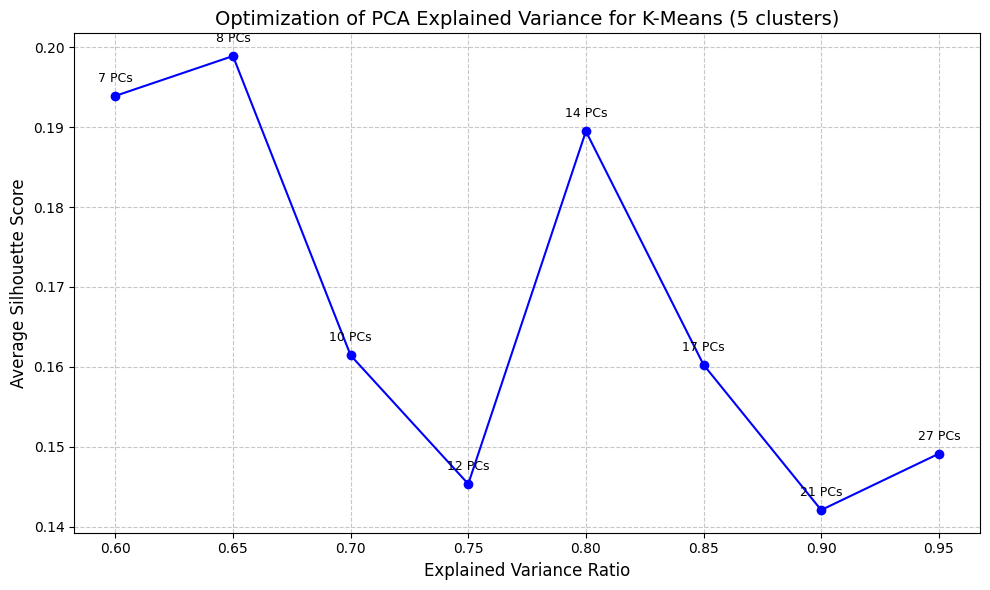

In [7]:
# Análise de Silhueta x Variância do PCA para Otimizar o K-Means

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def otimizar_pca_para_kmeans(X_scaled, numero_de_clusters):
    # 1. Definimos a grade de variâncias que queremos testar (de 60% a 95%, pulando de 5 em 5)
    niveis_variancia = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

    # Listas vazias para guardar os resultados
    escores_silhueta = []
    qnt_componentes = []

    # 2. O Loop de Experimentação
    for var in niveis_variancia:
        # A. Roda o PCA para o nível de variância atual da repetição
        pca_test_silhoutte = PCA(n_components=var, random_state=42)
        dados_pca = pca_test_silhoutte.fit_transform(X_scaled)
        
        # Guarda quantos componentes o PCA precisou para atingir essa variância
        qnt_componentes.append(pca_test_silhoutte.n_components_)
        
        # B. Roda o K-Means nos dados reduzidos
        kmeans = KMeans(n_clusters=numero_de_clusters, random_state=42)
        kmeans.fit(dados_pca)
        
        # C. Calcula e guarda o Escore de Silhueta
        score = silhouette_score(dados_pca, kmeans.labels_)
        escores_silhueta.append(score)

    # 3. Visualizando os Resultados
    plt.figure(figsize=(10, 6))

    # Plota a linha principal (Variância vs Silhueta)
    plt.plot(niveis_variancia, escores_silhueta, marker='o', linestyle='-', color='b')

    # Adiciona o número de componentes como rótulo em cada ponto para facilitar sua vida
    for i, txt in enumerate(qnt_componentes):
        plt.annotate(f"{txt} PCs", (niveis_variancia[i], escores_silhueta[i]), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    plt.title(f'Optimization of PCA Explained Variance for K-Means ({numero_de_clusters} clusters)', fontsize=14)
    plt.xlabel('Explained Variance Ratio', fontsize=12)
    plt.ylabel('Average Silhouette Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

numero_de_clusters = 5
otimizar_pca_para_kmeans(X_scaled, numero_de_clusters)

In [8]:
# Criação do PCA Final com o Número de Componentes Otimizado

def calcular_pca_final(X_scaled, num_componentes_pca):
    pca_final = PCA(n_components=num_componentes_pca) # num de componentes do PCA
    X_pca = pca_final.fit_transform(X_scaled)

    features = X.columns.tolist()

    # Criar um DataFrame com os componentes principais de cada instituição
    # Gerar dinamicamente os nomes das colunas: 'PC1', 'PC2', 'PC3', etc.
    nomes_componentes = [f'PC{i+1}' for i in range(X_pca.shape[1])]

    # Converter o array do PCA de volta para DataFrame do Pandas
    df_pca_puro = pd.DataFrame(
        X_pca, 
        columns=nomes_componentes, 
        index=df_filtrado.index # Mantém a mesma ordem das linhas original
    )
    df_var_pca = df_pca_puro.var()

    # Colar os identificadores ao lado dos componentes
    df_pca_valores = pd.concat([df_filtrado[['ano', 'cnpj', 'nome']], df_pca_puro], axis=1)

    # Criar um DataFrame com os pesos (Loadings)
    loadings = pd.DataFrame(
        pca_final.components_.T, 
        columns=[f'PC{i+1}' for i in range(num_componentes_pca)], 
        index=features
    )
    # Análise de Relevância dos Componentes do PCA
    # 1. Extrair a porcentagem de relevância de CADA componente do PCA
    relevancia_individual = pca_final.explained_variance_ratio_

    # 2. Calcular a relevância ACUMULADA (soma progressiva)
    relevancia_acumulada = np.cumsum(relevancia_individual)

    # 3. Criar uma tabela para visualizar (DataFrame Pandas)
    pca_relevancia = pd.DataFrame({
        'Componente': [f'PC{i+1}' for i in range(len(relevancia_individual))],
        'Variância Individual (%)': np.round(relevancia_individual * 100, 2),
        'Variância Acumulada (%)': np.round(relevancia_acumulada * 100, 2)
    })
    return X_pca, df_pca_valores, loadings, pca_relevancia

num_componentes_pca = 14
X_pca, df_pca_valores, loadings, pca_relevancia = calcular_pca_final(X_scaled, num_componentes_pca)

Criação e análises dos cluters

In [9]:
#Criação do modelo final de K-Means com o número de clusters otimizado

def criar_modelo_kmeans_final(X_pca, numero_de_clusters, df_filtrado, df_original):
    # Initialize and train the final model
    final_kmeans = KMeans(n_clusters=numero_de_clusters, init='k-means++', random_state=42, n_init='auto')
    final_kmeans.fit(X_pca)

    # Get the cluster labels for each bank
    cluster_labels = final_kmeans.labels_

    # Add the cluster labels to the original DataFrame
    df_filtrado['Cluster'] = cluster_labels
    df_filtrado.columns = df_filtrado.columns.astype(str)
    coluna_para_mover = df_filtrado.pop('Cluster')
    df_filtrado.insert(4, 'Cluster', coluna_para_mover)

    df_original['Cluster'] = cluster_labels
    df_original.columns = df_original.columns.astype(str)
    coluna_para_mover = df_original.pop('Cluster')
    df_original.insert(4, 'Cluster', coluna_para_mover) 

    # Save the results to a new CSV or update the SQLite database
    df_filtrado[['cnpj', 'Cluster']].to_csv('bank_clusters.csv', index=False)

    # Profile the clusters by calculating the mean of the original (unscaled) features for each cluster
    cluster_profiles = df_filtrado.groupby('Cluster')[X.columns].mean().sort_values(by='ativo realizavel - operacoes de credito', ascending=False)
#    cluster_profiles.to_csv('cluster_profiles.csv', index=False)
    return df_filtrado, df_original, final_kmeans, cluster_profiles

df_filtrado, df_original, final_kmeans, cluster_profiles = criar_modelo_kmeans_final(X_pca, numero_de_clusters, df_filtrado, df_original)

                                    Variavel_Original  Estatistica_H  \
0                 ativo realizavel - ativo realizavel    1711.427163   
5             ativo realizavel - operacoes de credito    1515.747512   
14              compensacao ativa - compensacao ativa    1791.996000   
19     compensacao ativa - operacoes de risco nivel a    1520.664581   
18  compensacao ativa - classificacao da carteira ...    2010.340249   
55  compensacao passiva - operacoes de creditos e ...    2010.340249   
54  compensacao passiva - classificacao da carteir...    2010.340249   
37  resultado credor - rendas de operacoes de credito    1637.284367   
50          compensacao passiva - compensacao passiva    1791.996000   
8   ativo realizavel - (-) provisoes para operacoe...    1258.308692   

          P-Valor  
0    0.000000e+00  
5    0.000000e+00  
14   0.000000e+00  
19   0.000000e+00  
18   0.000000e+00  
55   0.000000e+00  
54   0.000000e+00  
37   0.000000e+00  
50   0.000000e+00  
8   3.6

/tmp/ipykernel_422453/3842742193.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
/tmp/ipykernel_422453/3842742193.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')


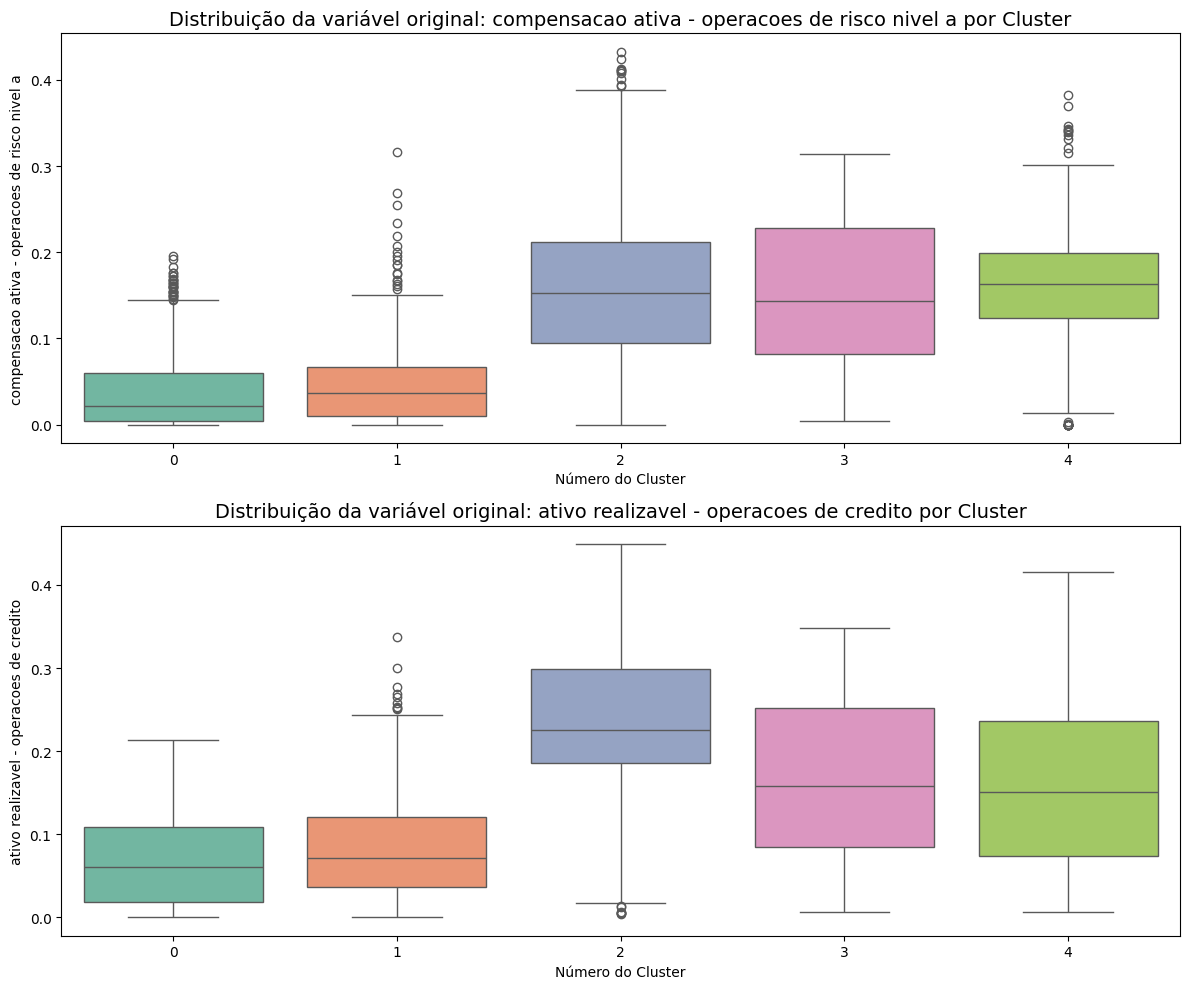

In [10]:
# Teste Kruskal-Wallis (não assume normalidade dos dados)

from scipy.stats import kruskal

def calcular_kruskal_clusters(df, coluna_cluster):
    resultados = []
    
    # Seleciona apenas variáveis numéricas (ignorando a coluna do cluster)
    colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
    colunas_numericas = [col for col in colunas_numericas if col != coluna_cluster]
    
    for coluna in colunas_numericas:
        # Separa a variável em listas, uma para cada cluster, removendo os NaNs
        grupos = [grupo[coluna].dropna() for nome, grupo in df.groupby(coluna_cluster)]
        
        # Como o Kruskal exige pelo menos 2 grupos com dados, fazemos uma checagem
        if len(grupos) > 1:
            stat, p_valor = kruskal(*grupos)
            
            resultados.append({
                'Variavel_Original': coluna,
                'Estatistica_H': stat,
                'P-Valor': p_valor
            })
            
    # Converte para DataFrame e ordena pelas variáveis mais significantes (menor p-valor)
    df_resultados = pd.DataFrame(resultados).sort_values(by='P-Valor')
    
    return df_resultados


# Vamos supor que o teste de Kruskal revelou que 'iip' e 'reser' são as melhores variáveis.
def plotar_boxplots_por_cluster(clusters):
    variaveis_top = ['compensacao ativa - operacoes de risco nivel a', 'ativo realizavel - operacoes de credito'] # Substitua pelas variáveis do topo da sua tabela

    # Configura o tamanho da figura para caber vários gráficos
    plt.figure(figsize=(12, 5 * len(variaveis_top)))

    for i, variavel in enumerate(variaveis_top):
        plt.subplot(len(variaveis_top), 1, i+1)
        
        # Plota o boxplot
        sns.boxplot(x='Cluster', y=variavel, data=clusters, palette='Set2')
        
        plt.title(f'Distribuição da variável original: {variavel} por Cluster', fontsize=14)
        plt.ylabel(variavel)
        plt.xlabel('Número do Cluster')

    plt.tight_layout()
    plt.show()

clusters = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'])
kruskal = calcular_kruskal_clusters(clusters, 'Cluster')
print(kruskal.head(10))
plotar_boxplots_por_cluster(df_filtrado)

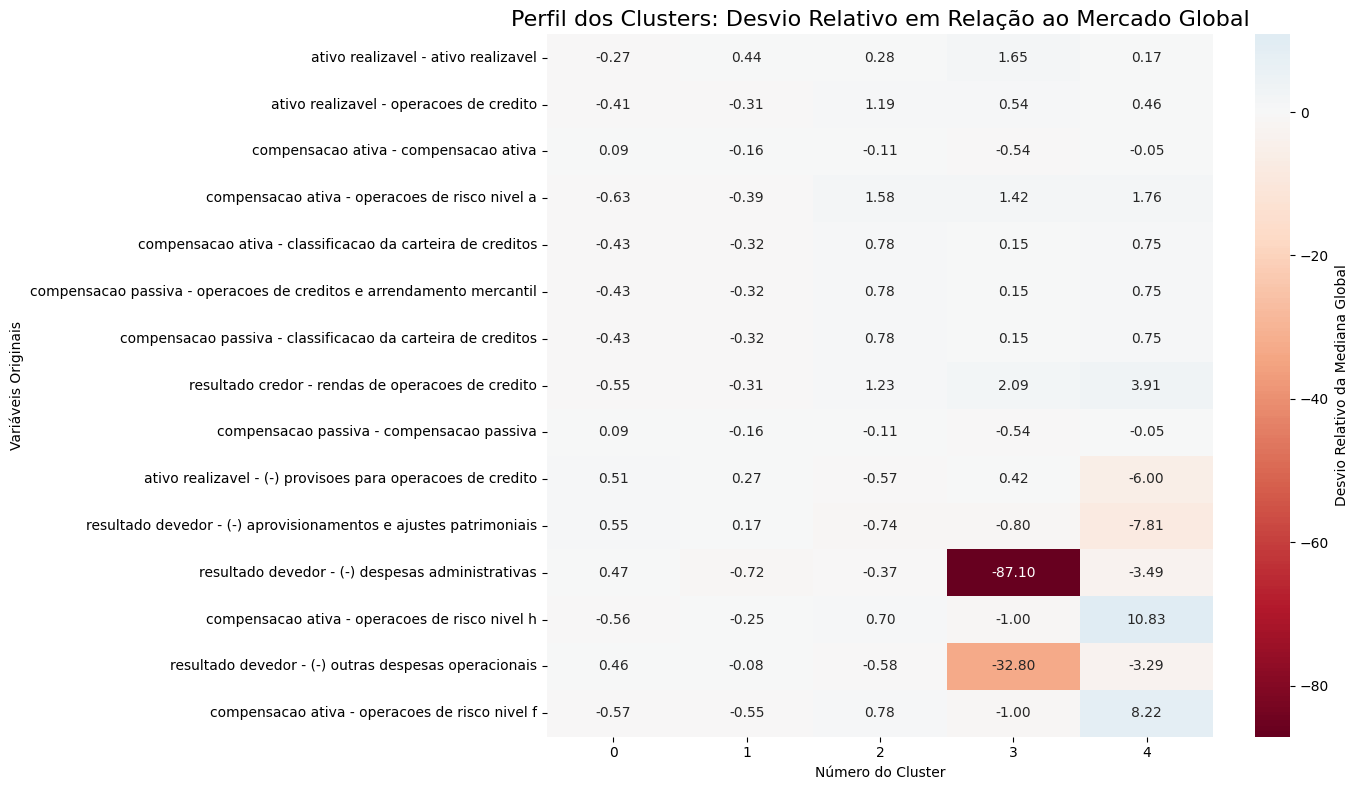

In [11]:
# Criando o Heatmap de Perfil dos Clusters com as Variáveis Originais

def plotar_heatmap_perfil_clusters(clusters, kruskal):
    clusters_filtrado = clusters
    '''[clusters['Cluster'] != 3]
    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 4]
    clusters_filtrado = clusters_filtrado[clusters_filtrado['Cluster'] != 2]'''

    # 1. Pegue as 15 variáveis mais importantes do seu teste de Kruskal-Wallis
    # (Assumindo que df_importancia é o resultado do código anterior)
    top_15_variaveis = kruskal['Variavel_Original'].head(15).tolist()

    # 2. Calcule a mediana global para essas 15 variáveis
    mediana_global = clusters_filtrado[top_15_variaveis].median()

    # 3. Calcule a mediana de cada cluster para essas 15 variáveis
    mediana_clusters = clusters_filtrado.groupby('Cluster')[top_15_variaveis].median()

    # 4. Calcule a variação percentual (ou relativa) do cluster vs o global
    # Isso normaliza os dados para o gráfico: 0 = igual ao global, > 0 acima, < 0 abaixo
    desvio_relativo = (mediana_clusters - mediana_global) / mediana_global.abs().replace(0, 1e-9) # Evita divisão por zero

    # 5. Plota o Heatmap
    plt.figure(figsize=(14, 8))
    sns.heatmap(desvio_relativo.T, # Transposto para variáveis ficarem nas linhas
                cmap='RdBu',       # Vermelho para abaixo da média, Azul para acima
                center=0,          # O branco será exatamente a média global
                annot=True,        # Mostra os números no gráfico
                fmt=".2f",         # 2 casas decimais
                cbar_kws={'label': 'Desvio Relativo da Mediana Global'})

    plt.title('Perfil dos Clusters: Desvio Relativo em Relação ao Mercado Global', fontsize=16)
    plt.xlabel('Número do Cluster')
    plt.ylabel('Variáveis Originais')
    plt.tight_layout()
    plt.show()


plotar_heatmap_perfil_clusters(df_filtrado, kruskal)

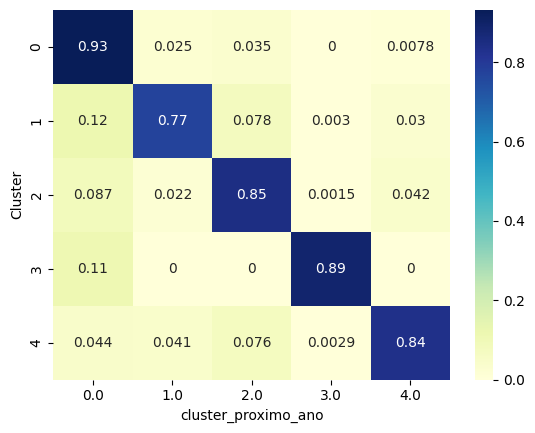

In [12]:
#Criar uma coluna com o cluster do ano seguinte para cada banco

def heatmap_cluster_proximo_ano(df_filtrado):
    df_sorted = df_filtrado.sort_values(['cnpj', 'ano'])
    df_sorted['cluster_proximo_ano'] = df_sorted.groupby('cnpj')['Cluster'].shift(-1)

    # 2. Criar a matriz de contagem/frequência
    matriz_transicao = pd.crosstab(
        df_sorted['Cluster'], 
        df_sorted['cluster_proximo_ano'], 
        normalize='index' # Transforma em porcentagem
    )

    sns.heatmap(matriz_transicao, annot=True, cmap='YlGnBu')

heatmap_cluster_proximo_ano(df_filtrado)

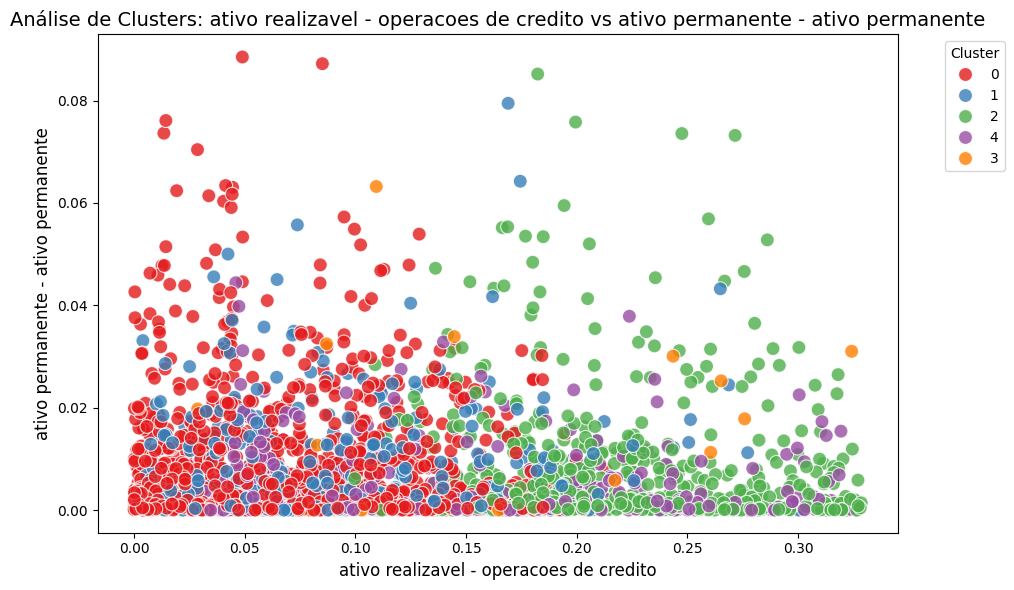

In [13]:
from scipy import stats

def plotar_scatter_clusters(df_filtrado, final_kmeans):
    df_viz = df_filtrado.copy()

    # Adicionamos uma nova coluna com os rótulos dos clusters gerados pelo K-Means
    # Transformamos em string (texto) para que o Seaborn entenda como categorias, não como números contínuos
    df_viz['Cluster'] = final_kmeans.labels_.astype(str)

    # 2. Configuração do Gráfico
    plt.figure(figsize=(10, 6)) # Define o tamanho da figura (largura, altura)

    # 3. Criando o Gráfico de Dispersão (Scatter Plot)
    # Escolha o par de contas do COSIF que você quer cruzar
    conta_x = 'ativo realizavel - operacoes de credito'
    conta_y = 'ativo permanente - ativo permanente'

    # Filtra mantendo apenas quem tem Z-score < 3 nos dois eixos
    df_viz = df_viz[
        (np.abs(stats.zscore(df_viz[conta_x])) < 2) &
        (np.abs(stats.zscore(df_viz[conta_y])) < 2)
    ]

    sns.scatterplot(
        data=df_viz, 
        x=conta_x, 
        y=conta_y, 
        hue='Cluster',        # Define a cor baseada na coluna 'Cluster'
        palette='Set1',       # Paleta de cores bem distinta
        s=100,                # Tamanho dos pontos
        alpha=0.8             # Transparência dos pontos (útil se houver sobreposição)
    )

    # 4. Ajustes estéticos (Títulos e Eixos)
    plt.title(f'Análise de Clusters: {conta_x} vs {conta_y}', fontsize=14)
    plt.xlabel(conta_x, fontsize=12)
    plt.ylabel(conta_y, fontsize=12)

    # Move a legenda para fora do gráfico para não cobrir os dados
    plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Otimiza o layout e exibe o gráfico
    plt.tight_layout()
    plt.show()

plotar_scatter_clusters(df_filtrado, final_kmeans)

In [14]:
import plotly.express as px

def plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, ano_especifico):
    df_viz = df_filtrado.copy()
    df_ano= df_viz[df_viz['ano'] == ano_especifico].copy()
    #df = px.data.X_scaled()
    features = ["ativo realizavel - operacoes de credito", "resultado credor - rendas de operacoes de credito", "resultado credor - receitas operacionais", "resultado devedor - (-) despesas operacionais"]

    fig = px.scatter_matrix(
        df_ano,
        dimensions=features,
        color="Cluster"
    )
    fig.update_traces(
        diagonal_visible=False,
        marker=dict(
            size=4,           # Reduz o tamanho (padrão costuma ser 6 ou 8)
            opacity=0.5,      # 40% de opacidade (permite ver através dos pontos)
            line=dict(width=0) # Remove a borda dos pontos para evitar "borrões" escuros
        )
    )

    fig.update_layout(
        title=f"Matriz de Dispersão - Safra {ano_especifico}",
        hovermode='closest'
    )

    fig.update_traces(diagonal_visible=False)
    fig.show()

plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, 2017)
plotar_scatter_matrix_clusters(df_filtrado, final_kmeans, 2018)

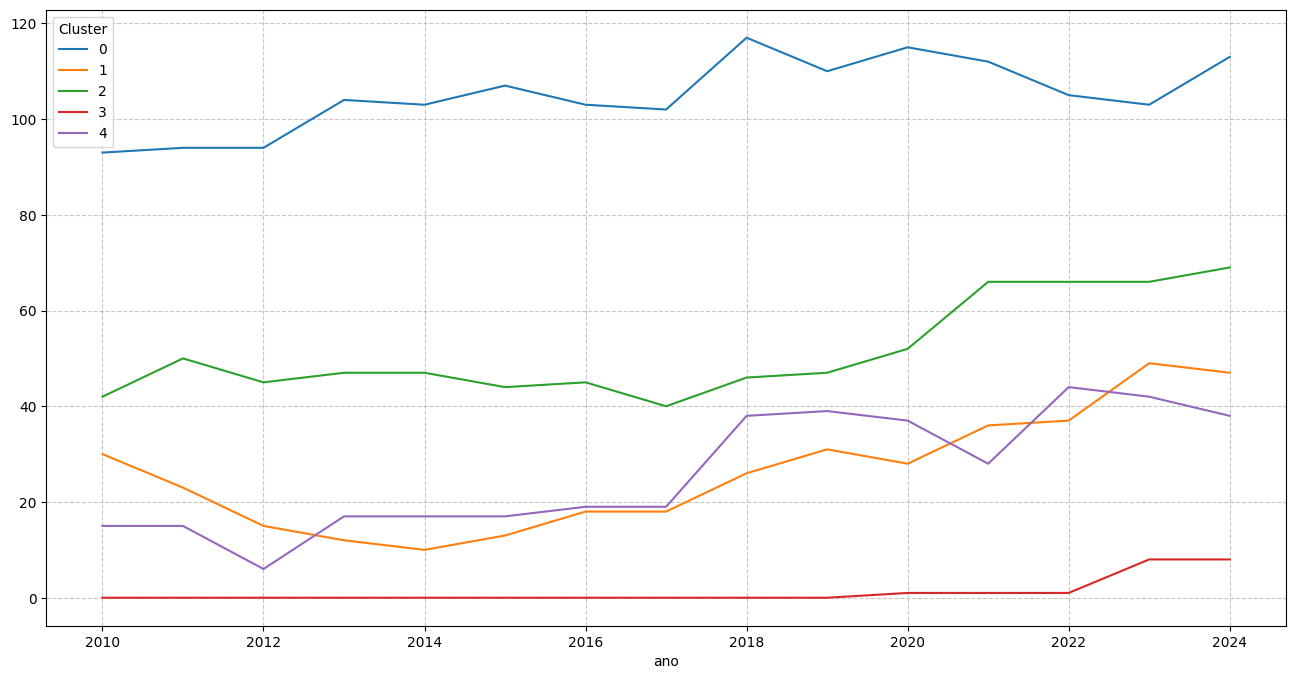

In [15]:
# Ver a evolução da quantidade de bancos em cada cluster por ano
def plotar_evolucao_clusters(df_filtrado):
    evolucao_clusters = df_filtrado.groupby(['ano', 'Cluster']).size().unstack().fillna(0)
    evolucao_clusters.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.grid(True, linestyle='--', alpha=0.7)

plotar_evolucao_clusters(df_filtrado)

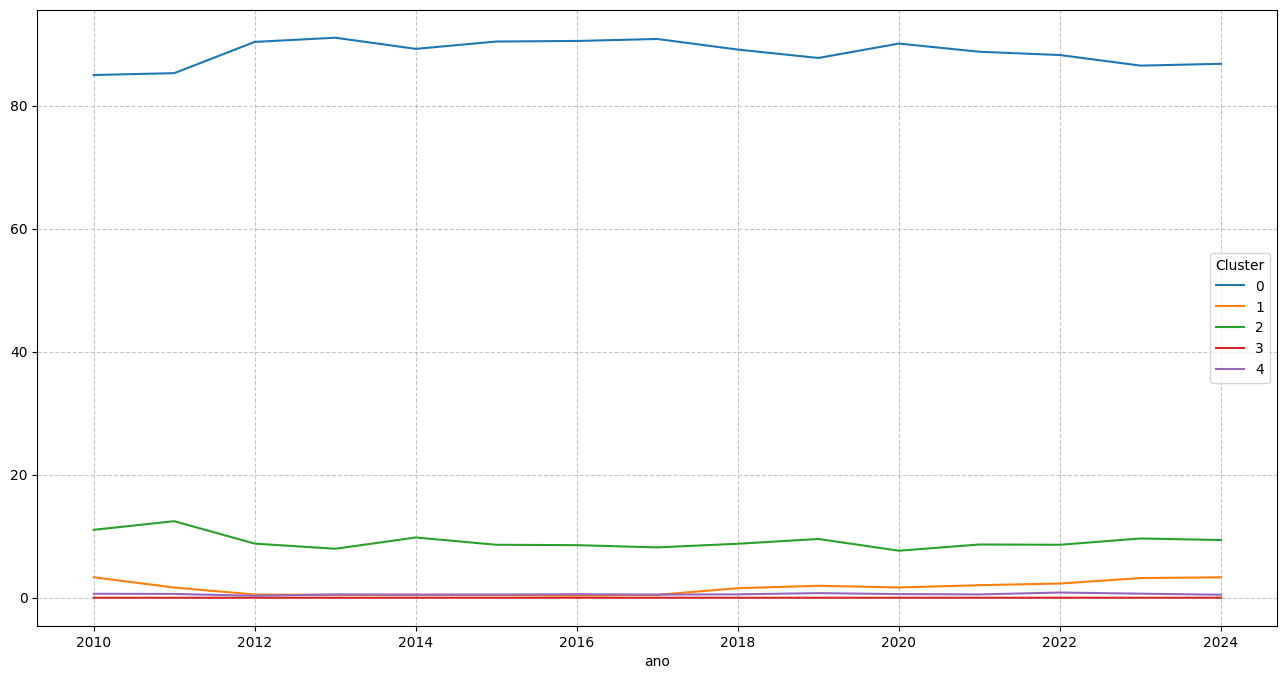

In [16]:
def calcular_market_share(df_original):
    share_individual = df_original.groupby(['ano', 'cnpj'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    share_individual.columns = ['ano', 'cnpj', 'credito_cnpj']

    share_individual['market_share'] = (
        share_individual['credito_cnpj'] / 
        share_individual.groupby('ano')['credito_cnpj'].transform('sum')
    )

    share_individual = pd.merge(share_individual, df_original[['ano','cnpj', 'nome', 'taxonomia', 'Cluster']], on=['ano', 'cnpj'], how='left')

    coluna_c = share_individual.pop('market_share')
    share_individual.insert(6, 'market_share', coluna_c)
    coluna_c = share_individual.pop('credito_cnpj')
    share_individual.insert(6, 'credito_cnpj', coluna_c)

    # 1. Agrupar por ano e cluster para somar o crédito
    share_df = df_original.groupby(['ano', 'Cluster'])['ativo realizavel - operacoes de credito'].sum().reset_index()

    # Renomear para clareza
    share_df.columns = ['ano', 'Cluster', 'credito_cluster']

    # 2. Calcular o total do mercado para cada ano e dividir o valor do cluster por esse total
    share_df['market_share'] = (
        share_df['credito_cluster'] / 
        share_df.groupby('ano')['credito_cluster'].transform('sum')
    )

    # Converter para porcentagem para facilitar a leitura
    share_df['market_share_pct'] = share_df['market_share'] * 100

    tabela_share = share_df.pivot(index='Cluster', columns='ano', values='market_share_pct').fillna(0)

    tabela_share.T.plot(kind='line', stacked=False, marker='', alpha=1, figsize=(16,8))
    plt.grid(True, linestyle='--', alpha=0.7)
    return share_individual

share_individual = calcular_market_share(df_original)

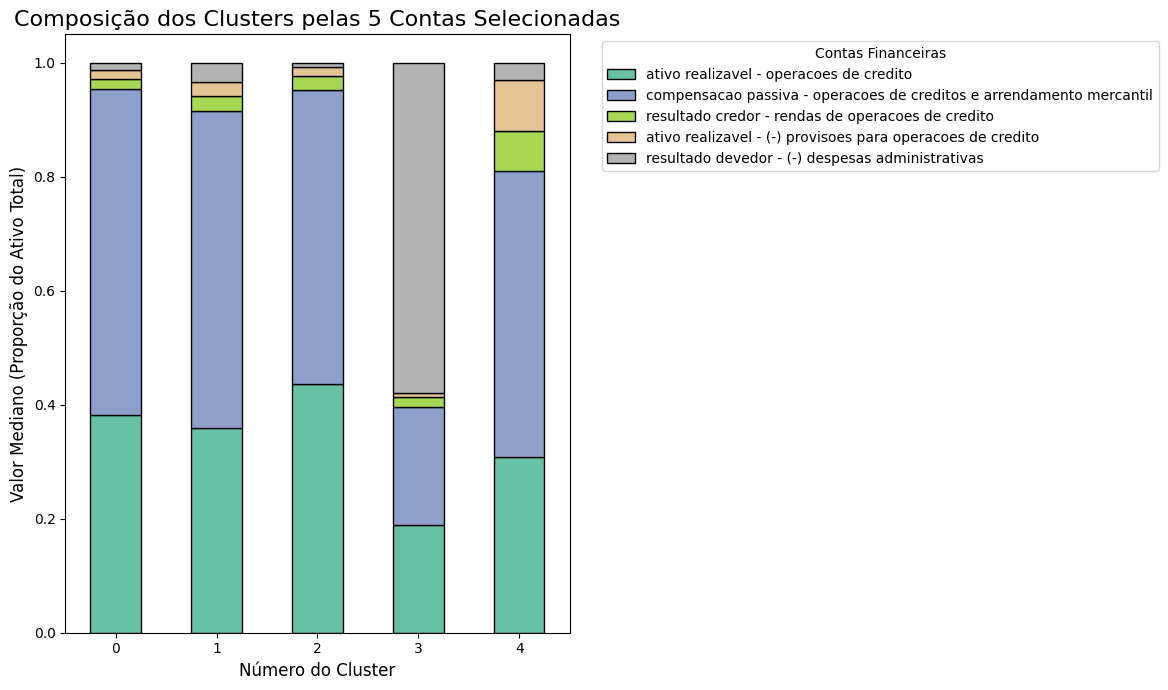

In [17]:
def plotar_barras_empilhadas_clusters(df_original):
    # 1. Defina as 5 variáveis (contas) que você quer analisar
    # Substitua pelos nomes exatos das colunas no seu DataFrame
    contas_escolhidas = ['ativo realizavel - operacoes de credito', 'compensacao passiva - operacoes de creditos e arrendamento mercantil', 'resultado credor - rendas de operacoes de credito', 'ativo realizavel - (-) provisoes para operacoes de credito', 'resultado devedor - (-) despesas administrativas']
    #contas_escolhidas = ['resultado credor - rendas de operacoes de credito', 'resultado devedor - (-) aprovisionamentos e ajustes patrimoniais', 'resultado devedor - (-) despesas administrativas', 'compensacao ativa - operacoes de risco nivel h', 'ativo realizavel - (-) provisoes para operacoes de credito']

    # 2. Agrupe os dados pelo Cluster e calcule a Mediana dessas 5 contas
    # Usamos a mediana para evitar que outliers distorçam a barra
    df_agrupado = df_original.groupby('Cluster')[contas_escolhidas].median().abs()
    df_agrupado = df_agrupado.div(df_agrupado.sum(axis=1), axis=0)

    # 3. Gere o Gráfico de Barras Empilhadas
    # O parâmetro 'stacked=True' é o que faz a mágica de empilhar
    fig, ax = plt.subplots(figsize=(12, 7))
    df_agrupado.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')

    # 4. Formatação para deixar com cara de apresentação executiva
    plt.title('Composição dos Clusters pelas 5 Contas Selecionadas', fontsize=16)
    plt.xlabel('Número do Cluster', fontsize=12)
    plt.ylabel('Valor Mediano (Proporção do Ativo Total)', fontsize=12)

    # Rotaciona os números do eixo X para ficarem retos
    plt.xticks(rotation=0) 

    # Move a legenda para fora do gráfico para não tampar as barras
    plt.legend(title='Contas Financeiras', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajusta o layout para a legenda não ser cortada ao salvar
    plt.tight_layout() 

    plt.show()

plotar_barras_empilhadas_clusters(df_original)

Modelo econométrico

In [18]:
# Dados de volatilidade de taxas de juros

def dados_juros():
    conn = sqlite3.connect('dados/banking.db')

    query = """
    SELECT
        *
    FROM
        media_volatilidade_anual
    """

    taxas_termo = pd.read_sql_query(query, conn)

    conn.close()

    taxas_termo['ano'] = taxas_termo['ano'].astype(int)
    return taxas_termo

taxas_termo = dados_juros()

In [35]:

def criar_modelo_final(df_filtrado, df_original, share_individual, taxas_termo):
    model  = df_filtrado[['ano', 'cnpj', 'nome', 'taxonomia','Cluster']].copy()
    df_original = df_original.fillna(0)

    # Net Interest Margin (nim)

    #model['nim'] = 100 * (df[['resultado credor - receitas operacionais', 'resultado devedor - (-) despesas de captacao']].sum(axis=1) / df_original['ativo realizavel - ativo realizavel'])

    model['nim'] = 100 * (df_original['resultado credor - receitas operacionais'] - df_original['resultado devedor - (-) despesas de captacao'].abs()) / df_original['ativo realizavel - ativo realizavel']

    # Market Structure (lerner/herf)

    share_individual['share_quadrado'] = share_individual['market_share'] ** 2
    hhi_anual = share_individual.groupby('ano')['share_quadrado'].sum().reset_index()
    hhi_anual.columns = ['ano', 'hhi']
    model = model.reset_index()

    model = pd.merge(
        model,
        hhi_anual,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None
    model['hhi'] = 100 * model['hhi']

    # Operating Costs (aoc)

    model['aoc'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['compensacao ativa - total geral do ativo'])

    # Degree of risk aversion (riskaver)

    model['riskaver'] = 100 * (df_original['patrimonio liquido - patrimonio liquido'] / df_original['compensacao ativa - total geral do ativo'])

    # Volatility of market interest rates (sd*)

    model = model.reset_index()
    model = pd.merge(
        model,
        taxas_termo,
        on=['ano'],
        how='left'
    )
    model = model.set_index('index')
    model.index.name = None

    # Credit Risk (crerisk)

    model['crerisk'] = 100 * (df_original['ativo realizavel - (-) provisoes para operacoes de credito'].abs() / df_original['ativo realizavel - operacoes de credito'])

    # Interaction between credit risk and market risk (sd*crerisk)

    model['sd_3m*crerisk'] = model['sd_annual_3m'] * model['crerisk'] / 100
    model['sd_1ano*crerisk'] = model['sd_annual_1ano'] * model['crerisk'] / 100
    model['sd_2anos*crerisk'] = model['sd_annual_2anos'] * model['crerisk'] / 100
    model['sd_3anos*crerisk'] = model['sd_annual_3anos'] * model['crerisk'] / 100
    model['sd_5anos*crerisk'] = model['sd_annual_5anos'] * model['crerisk'] / 100

    # Average size of operations/volume of loans (size)

    model['size'] = np.log10(df_original['ativo realizavel - operacoes de credito'])

    # Implicit interest payments (iip)

    model['iip'] = 100 * ((df_original['resultado devedor - (-) despesas operacionais'].abs() - df_original['resultado credor - rendas de prestacao de servicos']) / df_original['compensacao ativa - total geral do ativo'])

    # Opportunity costs of bank reserves (reser)

    model['reser'] = 100 * (df[['ativo realizavel - disponibilidades', 'ativo realizavel - aplicacoes interfinanceiras de liquidez']].sum(axis=1) / df_original['compensacao ativa - total geral do ativo'])

    #model['reser'] = 100 * ((df_original['ativo realizavel - disponibilidades'] + df_original['ativo realizavel - aplicacoes interfinanceiras de liquidez']) / df_original['compensacao ativa - total geral do ativo'])

    # Quality of management (ef)

    model['ef'] = 100 * (df_original['resultado devedor - (-) despesas operacionais'].abs() / df_original['resultado credor - receitas operacionais'])

    # Time dummies
    dummies_tempo = pd.get_dummies(model['ano'], drop_first=True)
    dummies_tempo = dummies_tempo.astype(int)
    model = pd.concat([model, dummies_tempo], axis=1)
    return model



model = criar_modelo_final(df_filtrado, df_original, share_individual, taxas_termo)

In [ ]:
# Para evitar que um banco que muda de cluster a cada ano tenha um "Cluster" diferente para cada linha, vamos fixar o cluster do banco pelo seu valor mais frequente (moda)

model_clusters_fixos =  model.copy(deep=True)
model_clusters_fixos['Cluster'] = model_clusters_fixos.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])

In [37]:
# POLS com Dummies de Cluster e Efeitos de Tempo (Time Dummies)

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

df_panel = model.set_index(['cnpj', 'ano'])
def rodar_modelo_panel(model):
    model['Cluster'] = model.groupby('cnpj')['Cluster'].transform(lambda x: x.mode()[0])
    df_panel = model.set_index(['cnpj', 'ano'])
    # 1. Transformar a coluna de clusters em Variáveis Dummy (0 ou 1)
    # O dtype=int garante que fique 0 e 1 em vez de True e False
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)

    # Juntamos essas dummies de volta ao nosso painel principal
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)

    # 2. Definir as Variáveis do Modelo
    # Incluímos as dummies dos Clusters 1, 2, 3 e 5. (O Cluster 0 fica de fora de propósito!)
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_4']

    # Incluímos os controles do balanço do banco
    # NOTA: Não inclua variáveis macro (como 'iip' ou 'sd_annual_3m') aqui, 
    # pois os Efeitos de Tempo já vão controlar tudo isso sozinhos.
    vars_controle = ['hhi', 'sd_annual_3m', 'sd_annual_3anos', 'crerisk', 'sd_3m*crerisk','sd_3anos*crerisk', 'size', 'riskaver', 'aoc', 'ef', 'iip', 'reser']

    df_panel = df_panel.loc[:, ~df_panel.columns.duplicated()]
    colunas_necessarias = ['nim'] + vars_controle + vars_dummies
    df_panel = df_panel.dropna(subset=colunas_necessarias)

    X = df_panel[vars_controle + vars_dummies]
    X = sm.add_constant(X)
    Y = df_panel['nim']

    # 3. Configurar e Rodar o Modelo
    # entity_effects=False: Fundamental para as dummies de Cluster sobreviverem
    # time_effects=True: Captura a influência macroeconômica específica de cada ano
    modelo_clusters = PanelOLS(Y, X, entity_effects=False, time_effects=True, drop_absorbed=True)

    # Usamos cluster_entity=True para corrigir a autocorrelação (já que desligamos o entity_effects)
    resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)

    print(resultados_clusters)

rodar_modelo_panel(model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                    nim   R-squared:                        0.4525
Estimator:                   PanelOLS   R-squared (Between):              0.6496
No. Observations:                3150   R-squared (Within):               0.3171
Date:                Wed, May 20 2026   R-squared (Overall):              0.4570
Time:                        18:19:37   Log-likelihood                -1.224e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      215.05
Entities:                         363   P-value                           0.0000
Avg Obs:                       8.6777   Distribution:                 F(12,3123)
Min Obs:                       1.0000                                           
Max Obs:                       15.000   F-statistic (robust):             33.101
                            

/tmp/ipykernel_422453/494289845.py:40: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

hhi, sd_annual_3m, sd_annual_3anos, reser

  resultados_clusters = modelo_clusters.fit(cov_type='clustered', cluster_entity=True)


In [43]:
# Fazendo uma regressão para cada ano

def rodar_regressoes_ano_a_ano(model):
    # 1. Defina as variáveis (SEM as variáveis macroeconômicas!)
    vars_controle = ['size', 'crerisk', 'iip', 'reser', 'ef', 'aoc', 'riskaver']
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_4'] # Base: Cluster 5
    # Adicione a dummy do Cluster 0 se você já a gerou, ou mantenha a estrutura que preferir

    # Dicionário para guardar a evolução do prêmio do Cluster 0 (exemplo)
    evolucao_coeficientes = {}

    df_panel = model.set_index(['cnpj', 'ano'])
    dummies_cluster = pd.get_dummies(df_panel['Cluster'], prefix='Cluster', dtype=int)
    df_panel = pd.concat([df_panel, dummies_cluster], axis=1)
    vars_dummies = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_4']


    # 2. Loop através de cada ano
    # Assumindo que o 'ano' está no nível 1 do seu MultiIndex
    anos = sorted(df_panel.index.get_level_values(1).unique())

    for ano in anos:
        # Filtra os dados apenas para o ano atual
        df_ano = df_panel.xs(ano, level=1)
        
        # Limpeza de nulos para o ano
        df_ano_clean = df_ano[['nim'] + vars_controle + vars_dummies].dropna()
        
        Y_ano = df_ano_clean['nim']
        X_ano = sm.add_constant(df_ano_clean[vars_controle + vars_dummies])
        
        try:
            # Roda um OLS tradicional com Erros Robustos de White (HC3)
            modelo_ano = sm.OLS(Y_ano, X_ano)
            resultados_ano = modelo_ano.fit(cov_type='HC3')
            
            # Guarda o coeficiente do Cluster_0 (ou Cluster_2) e o P-valor
            # Supondo que você quer rastrear a evolução do Cluster_2 neste exemplo
            evolucao_coeficientes[ano] = {
                'Coeficiente': resultados_ano.params['Cluster_2'],
                'P-valor': resultados_ano.pvalues['Cluster_2']
            }
        except Exception as e:
            print(f"Erro no ano {ano}: {e}")

    # 3. Transforma os resultados em uma tabela fácil de ler
    df_evolucao = pd.DataFrame.from_dict(evolucao_coeficientes, orient='index')
    print(df_evolucao)
    return df_evolucao

regressao_anual = rodar_regressoes_ano_a_ano(model)

      Coeficiente   P-valor
2010     8.706379  0.091414
2011     6.953633  0.073593
2012     4.298439  0.028261
2013     1.720527  0.385596
2014     4.498232  0.055617
2015     3.727330  0.247376
2016     9.709884  0.357325
2017    14.841591  0.278248
2018    15.012318  0.999998
2019    15.031099  0.999999
2020    26.854564  0.585114
2021    37.083254  0.999979
2022    13.009796  0.135613
2023    40.124136  0.032580
2024    17.415677  0.221723
